# 05 · EBM - the glass-box gradient booster

The **Explainable Boosting Machine** (InterpretML) is a modern GBDT variant that
trades a little flexibility for *total interpretability*. It fits a
**Generalized Additive Model with interactions (GA2M)**:

$$ g(\mathbb{E}[y]) = \beta_0 + \sum_j f_j(x_j) + \sum_{(j,k)} f_{jk}(x_j, x_k) $$

Each $f_j$ is a **shape function** learned by gradient boosting *one feature at a
time* in a round-robin. Because the model is a sum of per-feature functions, you
can read each function off exactly - no SHAP approximation needed. That makes it
the perfect tool to **verify our ground truth**.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
from utils import data as D
from utils import plotting as P
from sklearn.metrics import root_mean_squared_error, r2_score

df = pd.read_parquet("../data/regression.parquet")
y = df.pop("target")
X = df                                        # keeps 'category' as a categorical dtype
Xtr, Xte, ytr, yte = D.train_test_split_df(X, y, test_size=0.25, seed=0)


In [2]:
from interpret.glassbox import ExplainableBoostingRegressor

model = ExplainableBoostingRegressor(
    interactions=5,            # allow a few pairwise interaction terms
    max_bins=256, learning_rate=0.02, random_state=0,
)
model.fit(Xtr, ytr)
print("test RMSE:", round(root_mean_squared_error(yte, model.predict(Xte)), 3),
      "| R2:", round(r2_score(yte, model.predict(Xte)), 3))

test RMSE: 1.187 | R2: 0.951


## Reading the shape functions directly

`explain_global()` exposes each term's learned function. Let's plot the shape
functions for the linear feature **x0** (expect a straight line, slope ≈ 3) and
the nonlinear **x5** (expect a sine).

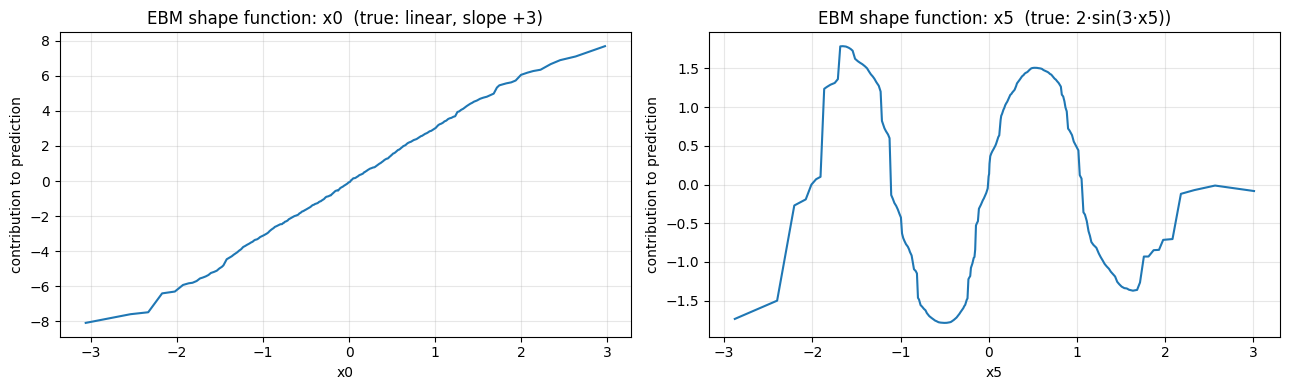

In [3]:
g = model.explain_global()
names = model.term_names_

def shape_of(feature):
    i = names.index(feature)
    d = g.data(i)
    return d  # dict with 'names' (bin edges) and 'scores'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (feat, note) in zip(axes, [("x0", "true: linear, slope +3"),
                                   ("x5", "true: 2·sin(3·x5)")]):
    d = shape_of(feat)
    xs = np.array(d["names"], dtype=float)
    xs = (xs[:-1] + xs[1:]) / 2 if len(xs) == len(d["scores"]) + 1 else xs[:len(d["scores"])]
    ax.plot(xs, d["scores"])
    ax.set(title=f"EBM shape function: {feat}  ({note})", xlabel=feat,
           ylabel="contribution to prediction")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Term importances vs the ground truth

EBM reports the mean absolute contribution of every term - main effects *and*
the interaction terms it chose. Noise features should sit near zero.

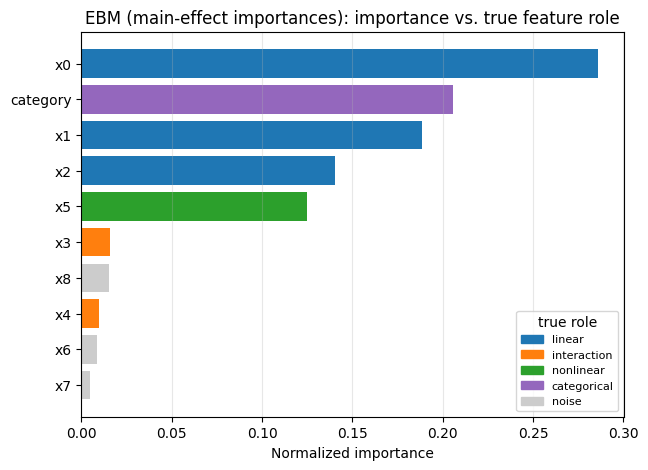

Interaction terms EBM discovered (look for an x3 & x4 term):
  x3 & x4               importance=1.464
  x1 & x4               importance=0.064
  x3 & x6               importance=0.062
  x3 & x7               importance=0.046
  x1 & x3               importance=0.038


In [4]:
_, _, gt = D.make_dataset("regression", n_samples=4000, seed=42)
overall = g.data()                      # overall importances
imp = dict(zip(overall["names"], overall["scores"]))
# Keep only single-feature terms for the truth comparison plot.
main = {k: v for k, v in imp.items() if k in X.columns}
P.plot_importance_vs_truth(main, gt, model_name="EBM (main-effect importances)")
plt.show()

print("Interaction terms EBM discovered (look for an x3 & x4 term):")
for k, v in sorted(imp.items(), key=lambda kv: -kv[1]):
    if "&" in k:
        print(f"  {k:20s}  importance={v:.3f}")

## A local explanation

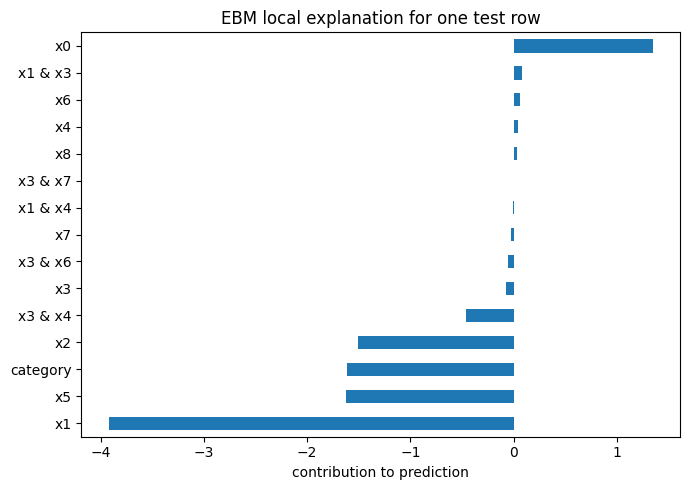

In [5]:
loc = model.explain_local(Xte.iloc[:1], yte.iloc[:1])
d = loc.data(0)
contribs = pd.Series(d["scores"], index=d["names"]).sort_values()
contribs.plot.barh(figsize=(7,5),
                   title="EBM local explanation for one test row")
plt.xlabel("contribution to prediction"); plt.tight_layout(); plt.show()

## Takeaways
- EBM is a **glass-box** booster: predictions are an exact sum of readable shape
  functions, so you can *verify* what it learned against ground truth.
- It correctly recovered the linear slopes, the sine, the category effect, the
  x3·x4 interaction, and ignored the noise.
- Accuracy is typically a hair behind the black-box trio - the price of full
  transparency.

Next: **`06_comparison_and_tuning`**.